# Comparative Analysis of BERT, DistilBERT, and RoBERTa on SST-2
**Author: Zhiren Xia | STATS 507 Final Project**

---

## 项目全局地图

| Step | 内容 | 你会学到什么 |
|------|------|-------------|
| 1 | 安装库 | 项目需要哪些工具 |
| 2 | 加载数据 | 什么是 SST-2，数据长什么样 |
| 3 | 数据预处理 | 什么是 Tokenizer，为什么需要它 |
| 4 | 训练模型 | 什么是 Fine-tune，怎么训练 |
| 5 | 评估对比 | 怎么比较三个模型的好坏 |
| 6 | 可视化 | 画图展示结果 |

**运行方式：** 从上到下，一个 cell 一个 cell 地按 `Shift + Enter` 运行。

---
## Step 1: 安装需要的库

我们需要以下工具：
- **transformers**: Hugging Face 的核心库，包含 BERT 等模型
- **datasets**: Hugging Face 的数据集库，可以一行代码下载 SST-2
- **evaluate**: 用来计算准确率等指标
- **torch**: PyTorch，深度学习框架（模型的"引擎"）
- **scikit-learn**: 经典机器学习库，我们用它来画混淆矩阵

👇 **运行下面这个 cell（只需要运行一次）：**

In [6]:
# 安装所有需要的库（只需运行一次）
# 如果某个库已经安装了，pip 会自动跳过
import sys
!{sys.executable} -m pip install transformers datasets evaluate torch scikit-learn matplotlib numpy pandas accelerate

  Using cached transformers-5.5.3-py3-none-any.whl.metadata (32 kB)
  Using cached datasets-4.8.4-py3-none-any.whl.metadata (19 kB)
  Using cached evaluate-0.4.6-py3-none-any.whl.metadata (9.5 kB)
  Using cached accelerate-1.13.0-py3-none-any.whl.metadata (19 kB)
  Using cached huggingface_hub-1.10.1-py3-none-any.whl.metadata (14 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl.metadata (7.3 kB)
  Using cached safetensors-0.7.0-cp38-abi3-macosx_11_0_arm64.whl.metadata (4.1 kB)
  Using cached hf_xet-1.4.3-cp37-abi3-macosx_11_0_arm64.whl.metadata (4.9 kB)
  Using cached dill-0.4.1-py3-none-any.whl.metadata (10 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached shellingham-1.5.4-

### 验证安装
运行下面的 cell，如果没有报错，说明安装成功：

In [7]:
import torch
import transformers
import datasets

print(f"PyTorch 版本: {torch.__version__}")
print(f"Transformers 版本: {transformers.__version__}")
print(f"Datasets 版本: {datasets.__version__}")

# 检查 Apple Silicon MPS 加速是否可用
# MPS = Metal Performance Shaders，是苹果芯片的 GPU 加速
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"\n✅ Apple MPS 加速可用！训练会更快")
else:
    device = torch.device("cpu")
    print(f"\n⚠️ MPS 不可用，将使用 CPU 训练（会慢一些但完全没问题）")

print(f"使用设备: {device}")

PyTorch 版本: 2.11.0
Transformers 版本: 5.5.3
Datasets 版本: 4.8.4

✅ Apple MPS 加速可用！训练会更快
使用设备: mps


---
## Step 2: 加载 SST-2 数据集

**SST-2 是什么？**
- 一个电影评论数据集
- 每条数据 = 一句话 + 一个标签（0=负面，1=正面）
- 训练集有 67,349 条，验证集有 872 条

我们用 Hugging Face 的 `datasets` 库一行代码就能下载：

In [8]:
from datasets import load_dataset

# 从 Hugging Face 下载 SST-2 数据集
# 第一次运行会下载（大约几十 MB），之后会用缓存
dataset = load_dataset("glue", "sst2")

# 看看数据集的结构
print("数据集结构:")
print(dataset)
print(f"\n训练集大小: {len(dataset['train'])} 条")
print(f"验证集大小: {len(dataset['validation'])} 条")

README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

数据集结构:
DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})

训练集大小: 67349 条
验证集大小: 872 条


In [9]:
# 看几条具体的数据，感受一下长什么样
print("=== 前 5 条训练数据 ===")
for i in range(5):
    example = dataset["train"][i]
    label = "正面 ✅" if example["label"] == 1 else "负面 ❌"
    print(f"\n[{i+1}] {label}")
    print(f"    句子: {example['sentence']}")

=== 前 5 条训练数据 ===

[1] 负面 ❌
    句子: hide new secretions from the parental units 

[2] 负面 ❌
    句子: contains no wit , only labored gags 

[3] 正面 ✅
    句子: that loves its characters and communicates something rather beautiful about human nature 

[4] 负面 ❌
    句子: remains utterly satisfied to remain the same throughout 

[5] 负面 ❌
    句子: on the worst revenge-of-the-nerds clichés the filmmakers could dredge up 


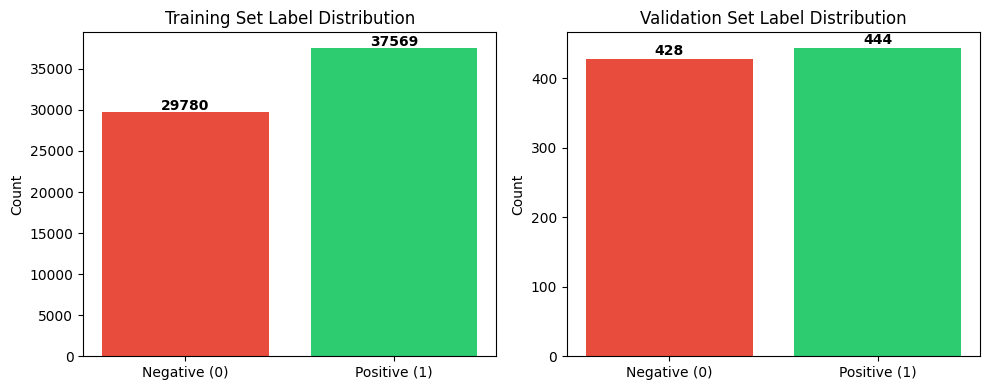


训练集: 29780 负面, 37569 正面
验证集: 428 负面, 444 正面


In [10]:
# 看看数据集的标签分布（正面 vs 负面 各有多少）
import matplotlib.pyplot as plt
import numpy as np

train_labels = dataset["train"]["label"]
val_labels = dataset["validation"]["label"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 训练集分布
counts_train = [train_labels.count(0), train_labels.count(1)]
axes[0].bar(["Negative (0)", "Positive (1)"], counts_train, color=["#E74C3C", "#2ECC71"])
axes[0].set_title("Training Set Label Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts_train):
    axes[0].text(i, v + 200, str(v), ha="center", fontweight="bold")

# 验证集分布
counts_val = [val_labels.count(0), val_labels.count(1)]
axes[1].bar(["Negative (0)", "Positive (1)"], counts_val, color=["#E74C3C", "#2ECC71"])
axes[1].set_title("Validation Set Label Distribution")
axes[1].set_ylabel("Count")
for i, v in enumerate(counts_val):
    axes[1].text(i, v + 5, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n训练集: {counts_train[0]} 负面, {counts_train[1]} 正面")
print(f"验证集: {counts_val[0]} 负面, {counts_val[1]} 正面")

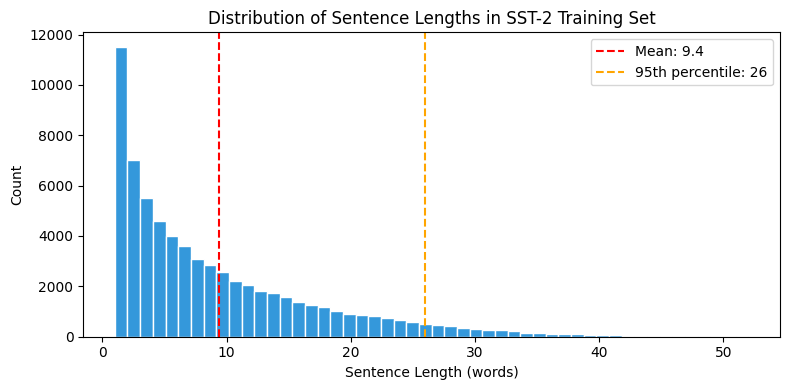

平均句子长度: 9.4 词
最长句子: 52 词
95% 的句子短于 26 词

→ 所以我们设 max_length=128 完全够用！


In [11]:
# 看看句子长度分布（帮助我们决定 max_length 设多少）
sentence_lengths = [len(s.split()) for s in dataset["train"]["sentence"]]

plt.figure(figsize=(8, 4))
plt.hist(sentence_lengths, bins=50, color="#3498DB", edgecolor="white")
plt.xlabel("Sentence Length (words)")
plt.ylabel("Count")
plt.title("Distribution of Sentence Lengths in SST-2 Training Set")
plt.axvline(x=np.mean(sentence_lengths), color="red", linestyle="--", label=f"Mean: {np.mean(sentence_lengths):.1f}")
plt.axvline(x=np.percentile(sentence_lengths, 95), color="orange", linestyle="--", label=f"95th percentile: {np.percentile(sentence_lengths, 95):.0f}")
plt.legend()
plt.tight_layout()
plt.savefig("sentence_lengths.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"平均句子长度: {np.mean(sentence_lengths):.1f} 词")
print(f"最长句子: {max(sentence_lengths)} 词")
print(f"95% 的句子短于 {np.percentile(sentence_lengths, 95):.0f} 词")
print(f"\n→ 所以我们设 max_length=128 完全够用！")

---
## Step 3: 数据预处理（Tokenization）

**为什么需要 Tokenizer？**

模型不能直接读懂英文句子，需要先把文字转成数字。这个过程叫做 **Tokenization（分词）**。

比如：`"This movie is great"` → `[1188, 2523, 1110, 1632]`

每个模型有自己的 Tokenizer（因为它们训练时用的"字典"不同）。

In [12]:
from transformers import AutoTokenizer

# 定义我们要对比的三个模型
# 这些是 Hugging Face 上的模型名称，就像"下载链接"
MODEL_NAMES = {
    "BERT":       "bert-base-uncased",
    "DistilBERT": "distilbert-base-uncased",
    "RoBERTa":    "roberta-base",
}

# 先用 BERT 的 tokenizer 演示一下 tokenization 的过程
demo_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# 用一句话演示
example_sentence = "This movie is absolutely fantastic!"
tokens = demo_tokenizer(example_sentence)

print(f"原始句子: {example_sentence}")
print(f"\nToken IDs: {tokens['input_ids']}")
print(f"\n还原回文字: {demo_tokenizer.convert_ids_to_tokens(tokens['input_ids'])}")
print(f"\n解释:")
print(f"  [CLS] = 句子开头标记（模型用这个位置来做分类）")
print(f"  [SEP] = 句子结尾标记")
print(f"  其他 = 实际的词或词片段")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

原始句子: This movie is absolutely fantastic!

Token IDs: [101, 2023, 3185, 2003, 7078, 10392, 999, 102]

还原回文字: ['[CLS]', 'this', 'movie', 'is', 'absolutely', 'fantastic', '!', '[SEP]']

解释:
  [CLS] = 句子开头标记（模型用这个位置来做分类）
  [SEP] = 句子结尾标记
  其他 = 实际的词或词片段


In [13]:
# 现在定义一个函数，把整个数据集都 tokenize
# 这个函数会被应用到数据集的每一条数据上

def tokenize_function(examples, tokenizer):
    """
    把句子转成模型能读懂的数字序列。
    
    参数:
        examples: 一批数据（包含多个句子）
        tokenizer: 对应模型的分词器
    
    返回:
        tokenized: 包含 input_ids, attention_mask 等
    """
    return tokenizer(
        examples["sentence"],
        padding="max_length",   # 不够长的句子用 0 补齐
        truncation=True,        # 太长的句子截断
        max_length=128,         # 最大长度 128（对 SST-2 足够了）
    )

print("✅ tokenize 函数定义完成")
print("\n下一步我们会对每个模型分别做 tokenization")

✅ tokenize 函数定义完成

下一步我们会对每个模型分别做 tokenization


---
## Step 4: 训练模型（Fine-tuning）

**什么是 Fine-tune（微调）？**

想象一下：BERT 就像一个读过上百万本书的学生。它已经"懂"英语了，但从来没做过"判断情感"这种考试。

Fine-tune 就是让这个学生做一些练习题（SST-2 训练集），让它学会如何判断正面/负面。因为它已经懂英语了，所以只需要少量练习就能学会。

**关键超参数（训练设置）：**
- `learning_rate`: 学习速度（太快会学不好，太慢会太慢）
- `num_train_epochs`: 把所有练习题做几遍
- `batch_size`: 每次同时看几道题

### ⏱️ 预计训练时间
在 Mac Apple Silicon 上，每个模型大约 **20-40 分钟**。三个模型一共约 **1-2 小时**。

如果你觉得太慢，可以把下面代码里的 `num_train_epochs` 改成 2。

In [14]:
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
)
import evaluate
import numpy as np
import time
import os

# 加载评估指标（准确率）
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    """计算评估指标：准确率"""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=predictions, references=labels)

# 保存所有模型的结果
all_results = {}

print("✅ 训练准备工作完成")
print(f"\n将要训练的模型: {list(MODEL_NAMES.keys())}")
print(f"每个模型训练 3 个 epoch")

✅ 训练准备工作完成

将要训练的模型: ['BERT', 'DistilBERT', 'RoBERTa']
每个模型训练 3 个 epoch


### 4.1 训练 BERT
第一个模型！运行下面的 cell 开始训练，你会看到进度条。

In [17]:
# ========== 训练 BERT ==========
model_name = "BERT"
model_path = MODEL_NAMES[model_name]
print(f"{'='*50}")
print(f"开始训练: {model_name} ({model_path})")
print(f"{'='*50}")

# 1. 加载 tokenizer 和模型
print("\n[1/4] 加载 tokenizer 和模型...")
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(
    model_path, 
    num_labels=2  # 二分类：正面/负面
)
print(f"  模型参数量: {sum(p.numel() for p in model.parameters()):,}")

# 2. Tokenize 数据集
print("\n[2/4] Tokenizing 数据集...")
tokenized_train = dataset["train"].map(
    lambda x: tokenize_function(x, tokenizer), batched=True
)
tokenized_val = dataset["validation"].map(
    lambda x: tokenize_function(x, tokenizer), batched=True
)

# 3. 设置训练参数
print("\n[3/4] 设置训练参数...")
training_args = TrainingArguments(
    output_dir=f"./results/{model_name}",     # 保存结果的文件夹
    num_train_epochs=3,                        # 训练 3 轮
    per_device_train_batch_size=16,             # 每次看 16 个样本
    per_device_eval_batch_size=32,              # 评估时每次 32 个
    learning_rate=2e-5,                         # 学习率
    weight_decay=0.01,                          # 防止过拟合
    eval_strategy="epoch",                      # 每个 epoch 结束评估一次
    save_strategy="epoch",                      # 每个 epoch 保存一次
    load_best_model_at_end=True,                # 最后加载最好的模型
    metric_for_best_model="accuracy",           # 用准确率判断哪个最好
    logging_steps=100,                          # 每 100 步打印一次 loss
    report_to="none",                           # 不上传到 wandb 等平台
)

# 4. 开始训练！
print("\n[4/4] 开始训练... ☕ 可以去倒杯水")
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

start_time = time.time()
train_result = trainer.train()
train_time = time.time() - start_time

# 5. 评估
eval_result = trainer.evaluate()

# 6. 保存结果
all_results[model_name] = {
    "accuracy": eval_result["eval_accuracy"],
    "train_time": train_time,
    "train_loss": train_result.training_loss,
    "eval_loss": eval_result["eval_loss"],
    "num_params": sum(p.numel() for p in model.parameters()),
    "log_history": trainer.state.log_history,
}

print(f"\n{'='*50}")
print(f"✅ {model_name} 训练完成!")
print(f"   准确率: {eval_result['eval_accuracy']:.4f} ({eval_result['eval_accuracy']*100:.1f}%)")
print(f"   训练时间: {train_time/60:.1f} 分钟")
print(f"{'='*50}")

开始训练: BERT (bert-base-uncased)

[1/4] 加载 tokenizer 和模型...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  模型参数量: 109,483,778

[2/4] Tokenizing 数据集...

[3/4] 设置训练参数...

[4/4] 开始训练... ☕ 可以去倒杯水


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

RuntimeError: on_train_begin must be called before on_evaluate

### 4.2 训练 DistilBERT
第二个模型，和 BERT 类似但更小更快：

In [18]:
# ========== 训练 DistilBERT ==========
model_name = "DistilBERT"
model_path = MODEL_NAMES[model_name]
print(f"{'='*50}")
print(f"开始训练: {model_name} ({model_path})")
print(f"{'='*50}")

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path, num_labels=2)
print(f"  模型参数量: {sum(p.numel() for p in model.parameters()):,}")

tokenized_train = dataset["train"].map(
    lambda x: tokenize_function(x, tokenizer), batched=True
)
tokenized_val = dataset["validation"].map(
    lambda x: tokenize_function(x, tokenizer), batched=True
)

training_args = TrainingArguments(
    output_dir=f"./results/{model_name}",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=100,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

print("\n开始训练... ☕")
start_time = time.time()
train_result = trainer.train()
train_time = time.time() - start_time

eval_result = trainer.evaluate()

all_results[model_name] = {
    "accuracy": eval_result["eval_accuracy"],
    "train_time": train_time,
    "train_loss": train_result.training_loss,
    "eval_loss": eval_result["eval_loss"],
    "num_params": sum(p.numel() for p in model.parameters()),
    "log_history": trainer.state.log_history,
}

print(f"\n{'='*50}")
print(f"✅ {model_name} 训练完成!")
print(f"   准确率: {eval_result['eval_accuracy']:.4f} ({eval_result['eval_accuracy']*100:.1f}%)")
print(f"   训练时间: {train_time/60:.1f} 分钟")
print(f"{'='*50}")

开始训练: DistilBERT (distilbert-base-uncased)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


RuntimeError: on_train_begin must be called before on_evaluate

### 4.3 训练 RoBERTa
最后一个模型，预期准确率最高：

In [19]:
# ========== 训练 RoBERTa ==========
model_name = "RoBERTa"
model_path = MODEL_NAMES[model_name]
print(f"{'='*50}")
print(f"开始训练: {model_name} ({model_path})")
print(f"{'='*50}")

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path, num_labels=2)
print(f"  模型参数量: {sum(p.numel() for p in model.parameters()):,}")

tokenized_train = dataset["train"].map(
    lambda x: tokenize_function(x, tokenizer), batched=True
)
tokenized_val = dataset["validation"].map(
    lambda x: tokenize_function(x, tokenizer), batched=True
)

training_args = TrainingArguments(
    output_dir=f"./results/{model_name}",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=100,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

print("\n开始训练... ☕")
start_time = time.time()
train_result = trainer.train()
train_time = time.time() - start_time

eval_result = trainer.evaluate()

all_results[model_name] = {
    "accuracy": eval_result["eval_accuracy"],
    "train_time": train_time,
    "train_loss": train_result.training_loss,
    "eval_loss": eval_result["eval_loss"],
    "num_params": sum(p.numel() for p in model.parameters()),
    "log_history": trainer.state.log_history,
}

print(f"\n{'='*50}")
print(f"✅ {model_name} 训练完成!")
print(f"   准确率: {eval_result['eval_accuracy']:.4f} ({eval_result['eval_accuracy']*100:.1f}%)")
print(f"   训练时间: {train_time/60:.1f} 分钟")
print(f"{'='*50}")

开始训练: RoBERTa (roberta-base)


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

RuntimeError: on_train_begin must be called before on_evaluate

---
## Step 5: 评估对比

三个模型都训练完了！现在来比较它们的表现。

In [20]:
import pandas as pd

# 汇总所有结果到一个表格
summary_data = []
for name, result in all_results.items():
    summary_data.append({
        "Model": name,
        "Accuracy (%)": f"{result['accuracy']*100:.2f}",
        "Parameters (M)": f"{result['num_params']/1e6:.1f}",
        "Training Time (min)": f"{result['train_time']/60:.1f}",
        "Train Loss": f"{result['train_loss']:.4f}",
        "Eval Loss": f"{result['eval_loss']:.4f}",
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*70)
print("              📊 模型对比总结")
print("="*70)
print(summary_df.to_string(index=False))
print("="*70)

# 保存为 CSV
summary_df.to_csv("model_comparison.csv", index=False)
print("\n结果已保存到 model_comparison.csv")


              📊 模型对比总结
Empty DataFrame
Columns: []
Index: []

结果已保存到 model_comparison.csv


---
## Step 6: 可视化

画图展示结果，这些图可以直接用在最终报告里。

ValueError: min() iterable argument is empty

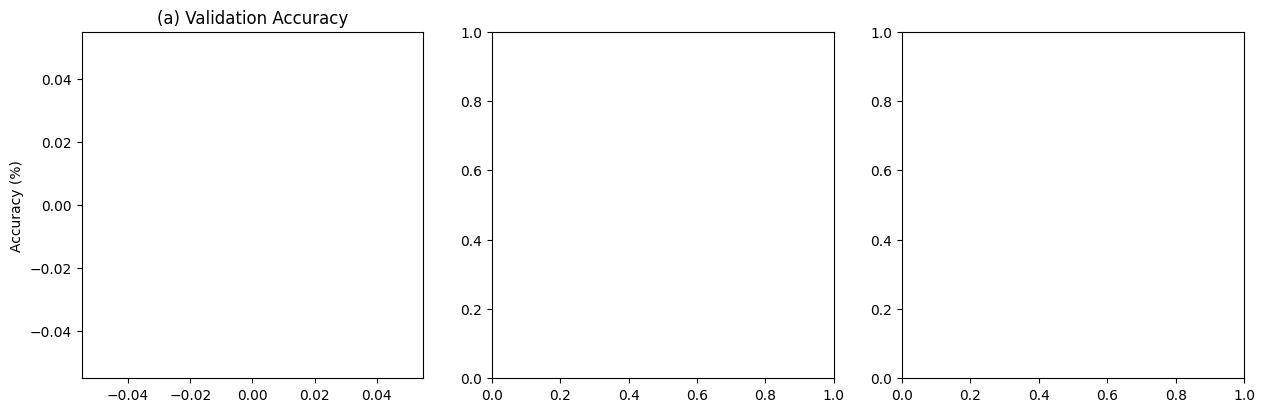

In [21]:
# 图 1: 准确率对比
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

models = list(all_results.keys())
colors = ["#4472C4", "#ED7D31", "#70AD47"]

# (a) Accuracy
accuracies = [all_results[m]["accuracy"] * 100 for m in models]
bars = axes[0].bar(models, accuracies, color=colors, width=0.5)
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("(a) Validation Accuracy")
axes[0].set_ylim(min(accuracies) - 3, max(accuracies) + 2)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.2,
                 f"{acc:.1f}%", ha="center", fontweight="bold")

# (b) Training Time
times = [all_results[m]["train_time"] / 60 for m in models]
bars = axes[1].bar(models, times, color=colors, width=0.5)
axes[1].set_ylabel("Time (minutes)")
axes[1].set_title("(b) Training Time")
for bar, t in zip(bars, times):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                 f"{t:.1f}m", ha="center", fontweight="bold")

# (c) Parameters
params = [all_results[m]["num_params"] / 1e6 for m in models]
bars = axes[2].bar(models, params, color=colors, width=0.5)
axes[2].set_ylabel("Parameters (millions)")
axes[2].set_title("(c) Model Size")
for bar, p in zip(bars, params):
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                 f"{p:.0f}M", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
print("图已保存为 model_comparison.png")

/var/folders/pm/9n59dytn3nn3f2by0wtkpwz40000gn/T/ipykernel_84723/4248591504.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
/var/folders/pm/9n59dytn3nn3f2by0wtkpwz40000gn/T/ipykernel_84723/4248591504.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


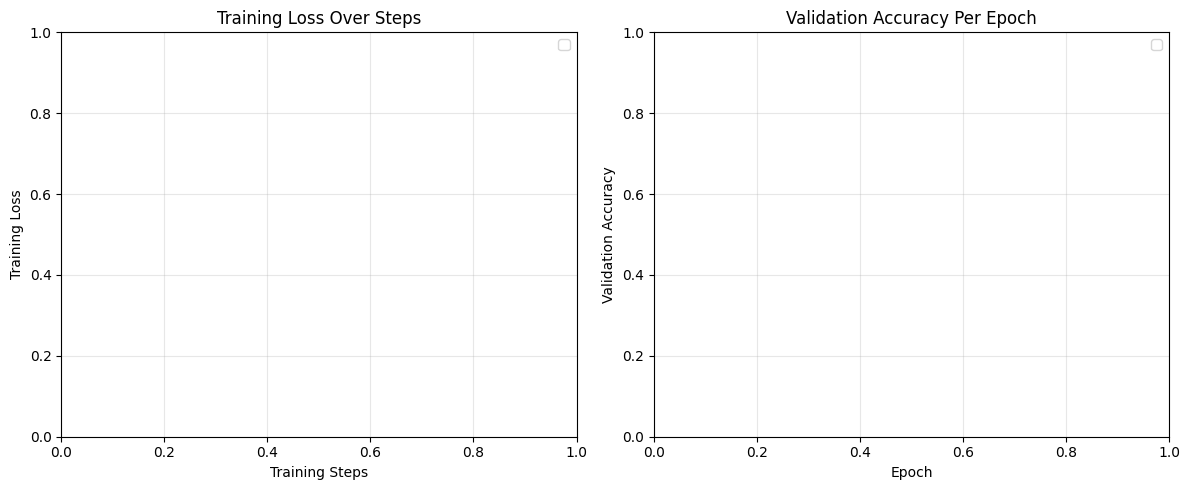

图已保存为 training_curves.png


In [22]:
# 图 2: 训练过程中 loss 的变化（Training Curves）
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for model_name, color in zip(models, colors):
    log_history = all_results[model_name]["log_history"]
    
    # 提取 training loss
    train_steps = [h["step"] for h in log_history if "loss" in h]
    train_losses = [h["loss"] for h in log_history if "loss" in h]
    
    # 提取 eval loss
    eval_epochs = [h["epoch"] for h in log_history if "eval_loss" in h]
    eval_losses = [h["eval_loss"] for h in log_history if "eval_loss" in h]
    eval_accs = [h["eval_accuracy"] for h in log_history if "eval_accuracy" in h]
    
    axes[0].plot(train_steps, train_losses, label=model_name, color=color, alpha=0.8)
    axes[1].plot(eval_epochs, eval_accs, marker="o", label=model_name, color=color, linewidth=2)

axes[0].set_xlabel("Training Steps")
axes[0].set_ylabel("Training Loss")
axes[0].set_title("Training Loss Over Steps")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Accuracy")
axes[1].set_title("Validation Accuracy Per Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=200, bbox_inches="tight")
plt.show()
print("图已保存为 training_curves.png")

正在生成预测结果...


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


IndexError: list index out of range

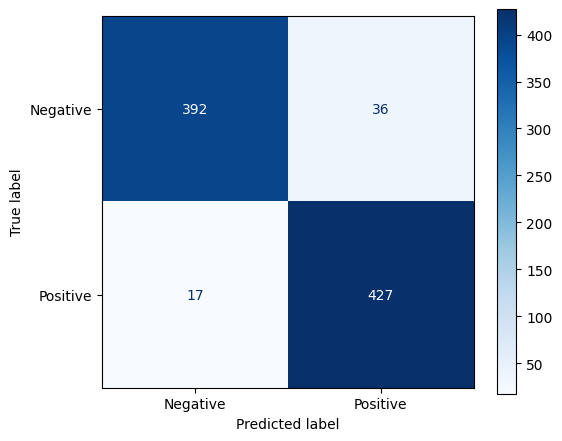

In [23]:
# 图 3: 混淆矩阵（Confusion Matrix）
# 展示模型在哪些地方判断对了，哪些地方判断错了

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 我们用最后训练的模型（RoBERTa）来做演示
# 如果你想看其他模型的混淆矩阵，可以重新加载对应模型

print("正在生成预测结果...")
predictions = trainer.predict(tokenized_val)
pred_labels = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

# 画混淆矩阵
cm = confusion_matrix(true_labels, pred_labels)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title(f"Confusion Matrix - {models[-1]}")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

# 详细分类报告
print("\n分类报告:")
print(classification_report(true_labels, pred_labels, target_names=["Negative", "Positive"]))

/var/folders/pm/9n59dytn3nn3f2by0wtkpwz40000gn/T/ipykernel_84723/3598725595.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10)


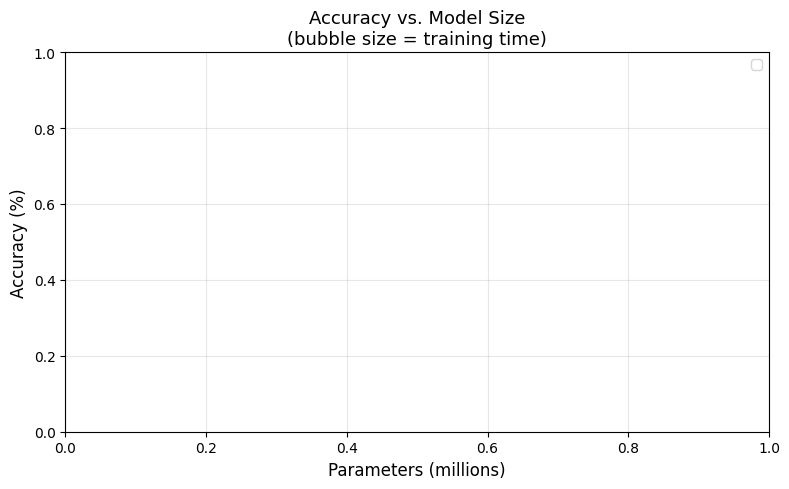

图已保存为 efficiency_accuracy.png


In [24]:
# 图 4: 效率-准确率散点图
# 展示每个模型的"性价比"

fig, ax = plt.subplots(figsize=(8, 5))

for i, model_name in enumerate(models):
    result = all_results[model_name]
    ax.scatter(
        result["num_params"] / 1e6,  # x: 参数量
        result["accuracy"] * 100,     # y: 准确率
        s=result["train_time"] * 3,   # 点的大小 = 训练时间
        c=colors[i],
        label=f"{model_name} ({result['train_time']/60:.0f}min)",
        edgecolors="black",
        linewidth=1,
        alpha=0.8,
        zorder=5,
    )

ax.set_xlabel("Parameters (millions)", fontsize=12)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("Accuracy vs. Model Size\n(bubble size = training time)", fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("efficiency_accuracy.png", dpi=200, bbox_inches="tight")
plt.show()
print("图已保存为 efficiency_accuracy.png")

---
## Step 7: 错误分析（Error Analysis）

看看模型在哪些句子上判断错了，这对写报告很有价值。

In [25]:
# 找出模型判断错误的例子
wrong_indices = np.where(pred_labels != true_labels)[0]

print(f"模型判断错误的样本数: {len(wrong_indices)} / {len(true_labels)}")
print(f"\n--- 错误样本示例 ---")

val_sentences = dataset["validation"]["sentence"]

for idx in wrong_indices[:10]:  # 只看前 10 个错误
    true = "正面 ✅" if true_labels[idx] == 1 else "负面 ❌"
    pred = "正面 ✅" if pred_labels[idx] == 1 else "负面 ❌"
    print(f"\n句子: {val_sentences[idx]}")
    print(f"  真实标签: {true}  |  模型预测: {pred}  ← 错误!")

模型判断错误的样本数: 53 / 872

--- 错误样本示例 ---

句子: the iditarod lasts for days - this just felt like it did . 
  真实标签: 负面 ❌  |  模型预测: 正面 ✅  ← 错误!

句子: the script kicks in , and mr. hartley 's distended pace and foot-dragging rhythms follow . 
  真实标签: 负面 ❌  |  模型预测: 正面 ✅  ← 错误!

句子: you wo n't like roger , but you will quickly recognize him . 
  真实标签: 负面 ❌  |  模型预测: 正面 ✅  ← 错误!

句子: if steven soderbergh 's ` solaris ' is a failure it is a glorious failure . 
  真实标签: 正面 ✅  |  模型预测: 负面 ❌  ← 错误!

句子: this riveting world war ii moral suspense story deals with the shadow side of american culture : racial prejudice in its ugly and diverse forms . 
  真实标签: 负面 ❌  |  模型预测: 正面 ✅  ← 错误!

句子: it 's difficult to imagine the process that produced such a script , but here 's guessing that spray cheese and underarm noises played a crucial role . 
  真实标签: 负面 ❌  |  模型预测: 正面 ✅  ← 错误!

句子: hilariously inept and ridiculous . 
  真实标签: 正面 ✅  |  模型预测: 负面 ❌  ← 错误!

句子: sam mendes has become valedictorian at the school f

---
## 🎉 完成！

你现在已经：
1. ✅ 加载了 SST-2 数据集
2. ✅ Fine-tune 了 BERT、DistilBERT、RoBERTa 三个模型
3. ✅ 对比了它们的准确率、速度和大小
4. ✅ 生成了可视化图表
5. ✅ 做了错误分析

### 生成的文件
- `model_comparison.csv` - 结果汇总表
- `label_distribution.png` - 数据集标签分布图
- `sentence_lengths.png` - 句子长度分布图
- `model_comparison.png` - 三模型对比图
- `training_curves.png` - 训练曲线
- `confusion_matrix.png` - 混淆矩阵
- `efficiency_accuracy.png` - 效率-准确率图

### 下一步
- 把代码上传到 GitHub 仓库
- 用这些结果和图表写最终的 IEEE 格式报告
- 可以把这个 notebook 发给我，我帮你生成最终报告